# **Lab 4.1 Data Augmentation with PyTorch**

In [13]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1 import ImageGrid

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return DataLoader() and print the information about the Dataset.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>), [`ImageFolder`](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html), [`Dataloader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#:~:text=Preparing%20your%20data%20for%20training%20with%20DataLoaders)

In [2]:
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Pad(padding=223, padding_mode='reflect'),
        transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])

    dataset = ImageFolder(path, transform=transform)

    data_loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
    
    print("📃Train Dataset:")
    for i, cl in enumerate(dataset.classes):
        print(f"Number of images in class {cl}: {dataset.targets.count(i)}")
    print("Number of samples:", len(dataset))
    
    return data_loader
    ### END CODE HERE ###

Use your load_data() function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/01.png?raw=true)

</details>

📃Train Dataset:
Number of images in class battleship: 44
Number of images in class patrol boat: 35
Number of images in class submarine: 35
Number of samples: 114


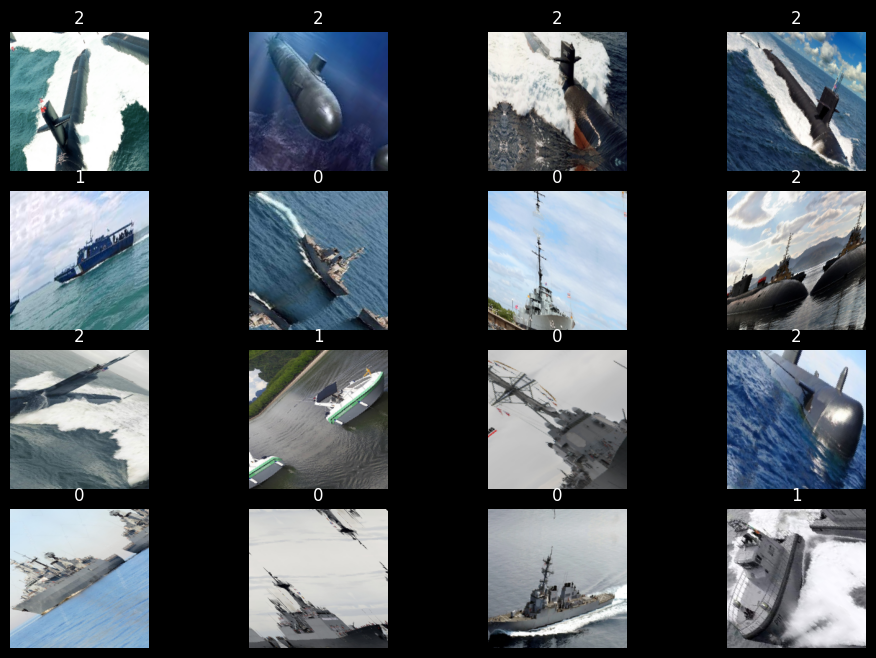

In [3]:
### START CODE HERE ###
data_loader = load_data("ship/train")

first_batch = next(iter(data_loader))

images, labels = first_batch

fig = plt.figure(figsize=(20, 8))
grid = ImageGrid(fig, rect=111 , nrows_ncols=(4, 4), axes_pad=(1, 0.2))

for i, ax in enumerate(grid):
    channel_last = images[i].permute(1, 2, 0)
    im = ax.imshow(channel_last)
    ax.set_title(labels[i].item())
    ax.set_axis_off()
        
plt.show()
### END CODE HERE ###

Now, let's create your own `CustomImageDataset` that performs the augmentation as in the previous section, but also includes the methods `add_gaussian_blur()` and `add_gaussian_noise()`. **<font color="red">DO NOT</font>** use `transforms.Compose()`.

Resource : [CustomImageDataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#:~:text=.show()-,Dataset%20class,-torch.utils.data)

In [4]:
### START CODE HERE ###
class CustomImageDataset(Dataset):
    def __init__(self, root_dir):
        self.dataset = ImageFolder(root_dir)
        
    def add_gaussian_blur(self, image):
        blur_transform = transforms.GaussianBlur(kernel_size=21, sigma=(0.1, 2.0))
        return blur_transform(image)
    
    def add_gaussian_noise(self, image, mean=0.0, std=0.1):
        image = transforms.ToTensor()(image)
        noise = torch.randn_like(image) * std + mean
        noisy_image = image + noise
        noisy_image = torch.clamp(noisy_image, 0., 1.)
        return transforms.ToPILImage()(noisy_image)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        try:
            image, label = self.dataset[idx]

            image = self.add_gaussian_blur(image)
            image = self.add_gaussian_noise(image)
            
            image = transforms.Resize((224, 224))(image)
            image = transforms.Pad(padding=224, padding_mode='reflect')(image)
            image = transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)(image)
            image = transforms.CenterCrop(224)(image)
            
            image = transforms.ToTensor()(image)
        
            return image,label
        
        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            raise e
    
### END CODE HERE ###

Use your `CustomImageDataset()` function. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/02.png?raw=true)

</details>

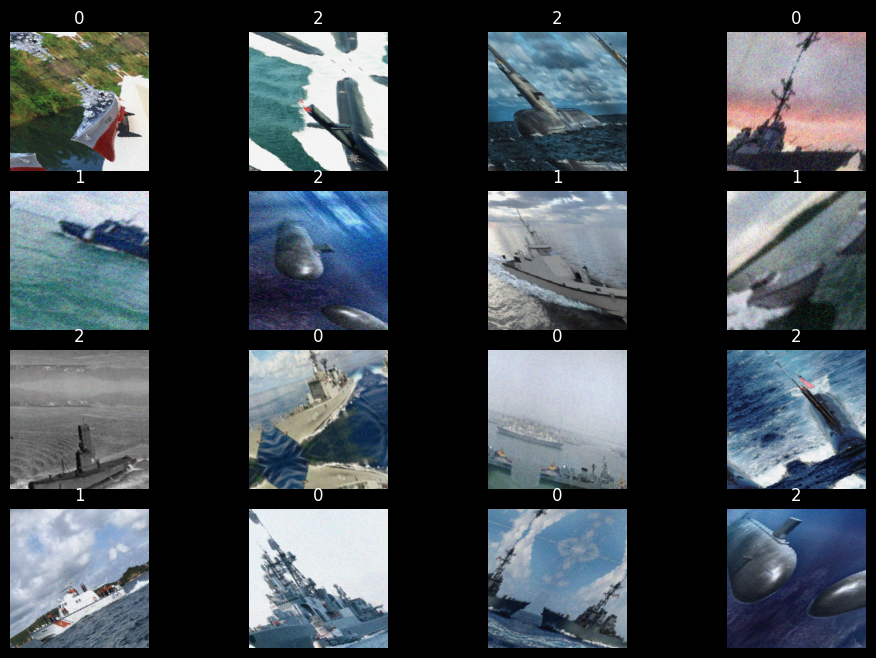

In [5]:
### START CODE HERE ###
dataset = CustomImageDataset("ship/train")
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

first_batch = next(iter(dataloader))

images, labels = first_batch

fig = plt.figure(figsize=(20, 8))
grid = ImageGrid(fig, rect=111 , nrows_ncols=(4, 4), axes_pad=(1, 0.2))

for i, ax in enumerate(grid):
    channel_last = images[i].permute(1, 2, 0)
    im = ax.imshow(channel_last)
    ax.set_title(labels[i].item())
    ax.set_axis_off()
        
plt.show()
### END CODE HERE ###

---

## **Question** 
1. Discuss effects and benefits of fill_mode or padding_mode.
2. What would be amount of augmentation should be so that it would not effect the training performance?
3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality?
4. What would be transform parameter to simulate camera lense effect?

## **Answers**
1. fill_mode หรือ padding_mode ทำให้พื้นที่ว่างที่เกิดจากการ transform ถูกเติม เช่น reflect เป็นการสะท้อน pixel บริเวณขอบ ประโยชน์คือจะทำให้ภาพที่ได้ดูสมจริงและเนียมกว่าเดิม
2. แต่ละภาพควรมี augmentation ไม่เกิน 4 ต่อภาพ เพราะถ้าใช้มากเกินไป จะทำให้ภาพที่ได้ต่างจะเดิมมากเกินไปจนเมื่อนำไป train โมเดลจะเรียนรู้ผิด และยิ่งมี augmentation มากก็จะใช้เวลามาก ทำให้ train ได้ช้าลง
3. Salt and Pepper เป็น noise ประเภทหนึ่งที่ สุ่มเปลี่ยนค่า pixel ในภาพบางจุดให้เป็น ดำ หรือ ขาว โดยมีขั้นตอนคือ กำหนดอัตรา noise เช่น 2% ของ pixel ทั้งหมด จากนั้น กำหนดอัตราส่วนระหว่าง salt กับ pepper อาจเป็น ครึ่ง ๆ (50%, 50%) จากนั้นสุ่มเลือก pixel แล้วเปลี่ยน
4. แล้วแต่แบบ เช่น เลนส์กล้องหลุดโฟกัส ก็ใช้ transforms.GaussianBlur, เลนส์กล้องเอียง ก็ใช้ transforms.RandomPerspective, เลนส์กล้องซูม ก็ใช้ transforms.RandomResizedCrop